<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week13_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

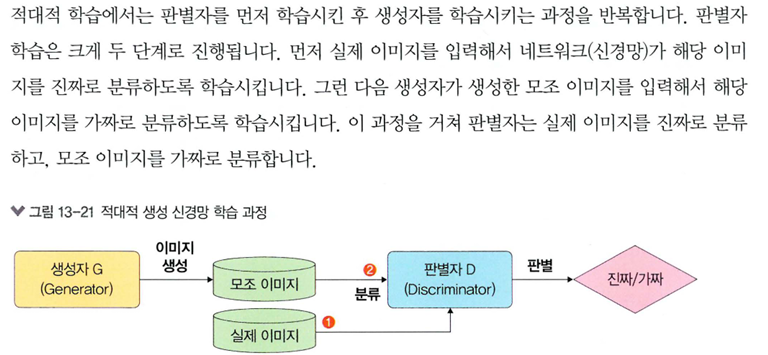

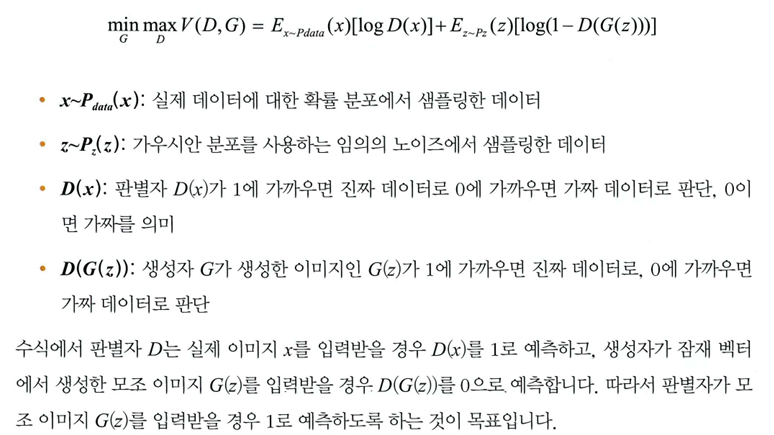

이때 생성자 입장에서는 D(G(z))=l이 최상의 결과(판별자가 가짜 이미지를 1로 출력한 경우)가
될 것이기 때문에 이 식의 최솟값으로 업데이트해야 합니다.
참고로 GAN을 학습시키려면 판별자와 생성자의 파라미터를 번갈아 가며 업데이트해야 합니다.
또한， 판별자의 파라미터를 업데이트할 때는 생성자의 파라미터를 고정시키고， 생성자의 파라미
터를 업데이트할 때는 판별자의 파라미터를 고정해야 합니다.

In [3]:
import imageio
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib
from torchvision.utils import save_image, make_grid
import torchvision.datasets as datasets
import torchvision.transforms as transforms
matplotlib.style.use('ggplot') #격자무늬 생성
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
batch_size=512
epochs=200
sample_size=64
nz=128
k=1

In [17]:
transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),
])
train_dataset=datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [6]:
# 생성자 네트워크

class Generator(nn.Module):
  def __init__(self,nz):
    super(Generator,self).__init__()
    self.nz=nz
    self.main=nn.Sequential(
        nn.Linear(self.nz,256),
        nn.LeakyReLU(0.2),
        nn.Linear(256,512),
        nn.LeakyReLU(0.2),
        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),
        nn.Linear(1024,784),
        nn.Tanh()
    )
  def forward(self,x):
    return self.main(x).view(-1,1,28,28)


In [7]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator,self).__init__()
    self.n_input=784
    self.main=nn.Sequential(
        nn.Linear(self.n_input,1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024,512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512,256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    x=x.view(-1,784)
    return self.main(x)

In [8]:
generator=Generator(nz).to(device)
discriminator=Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [9]:
# 중요한 것은 생성자와 판별자에서 사용할 옵티마이저를 따로 정의해야 한다는 것

optim_g=optim.Adam(generator.parameters(),lr=0.0002)
optim_d=optim.Adam(discriminator.parameters(),lr=0.0002)

criterion=nn.BCELoss()

losses_g=[]
losses_d=[]
images=[]

In [15]:
#생성자에 의해 만들어지는 새로운 이미지(댄서)를 저장하기 위한 함수를 저장

def save_generator_image(image,path):
  save_image(image,path)


In [25]:
def train_discriminator(optimizer,data_real,data_fake):
  b_size=data_real.size(0)
  real_label=torch.ones(b_size,1).to(device)
  fake_label=torch.zeros(b_size,1).to(device)
  optimizer.zero_grad()
  output_real=discriminator(data_real)
  loss_real=criterion(output_real,real_label)
  output_fake=discriminator(data_fake)
  loss_fake=criterion(output_fake,fake_label)
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  loss=loss_real+loss_fake
  return loss.item()

In [26]:
#생성자 입장에서는 가짜 데이터가 실제로 진짜라는 것에 주의
def train_generator(optimizer,data_fake):
  b_size=data_fake.size(0)
  real_label=torch.ones(b_size,1).to(device)
  optimizer.zero_grad()
  output=discriminator(data_fake)
  loss=criterion(output,real_label)
  loss.backward()
  optimizer.step()
  return loss.item()

In [27]:
batch_size = 64

epochs = 30

generator.train()
discriminator.train()

for epoch in range(epochs):
  loss_g=0.0
  loss_d=0.0
  for idx,data in tqdm(enumerate(train_loader),total=int(len(train_dataset)/train_loader.batch_size)):
    image,_=data
    image=image.to(device)
    b_size=len(image)
    for step in range(k):
      data_fake=generator(torch.randn(b_size,nz).to(device)).detach()
      data_real=image
      loss_d+=train_discriminator(optim_d,data_real,data_fake)
    data_fake=generator(torch.randn(b_size,nz).to(device))
    loss_g+=train_generator(optim_g,data_fake)
  generated_img=generator(torch.randn(b_size,nz).to(device)).cpu().detach()
  generated_img=make_grid(generated_img)
  save_generator_image(generated_img,f"/content/data/gen_img{epoch}.png")
  epoch_loss_g=loss_g/idx
  epoch_loss_d=loss_d/len(train_loader)
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)

  print(f'Epoch {epoch} of {epochs}')
  print(f'Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}')






/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
938it [00:22, 42.13it/s]                         

Epoch 0 of 30
Generator loss: 100.10672359, Discriminator loss: 0.00000000



938it [00:22, 40.86it/s]                         

Epoch 1 of 30
Generator loss: 100.10672359, Discriminator loss: 0.00000000



938it [00:23, 40.66it/s]                         

...

Epoch 27 of 30
Generator loss: 100.10672359, Discriminator loss: 0.00000000



938it [00:22, 41.25it/s]                         

Epoch 28 of 30
Generator loss: 100.10672359, Discriminator loss: 0.00000000



938it [00:22, 40.79it/s]                         

Epoch 29 of 30
Generator loss: 100.10672359, Discriminator loss: 0.00000000


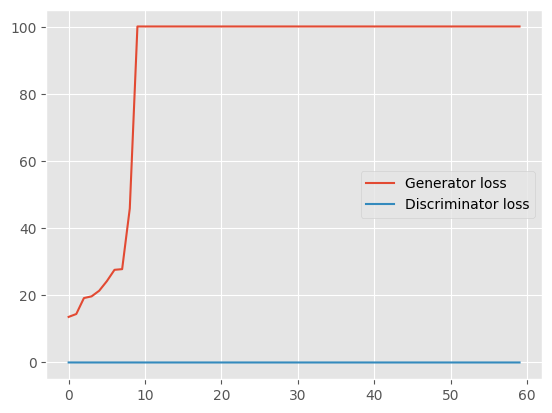

In [29]:
plt.figure()

plt.plot(losses_g,label='Generator loss')

plt.plot(losses_d,label='Discriminator loss')
plt.legend()
plt.show()

In [ ]:
fake_images=generator(torch.randn(b_size,nz).to(device))
import numpy as np
for i in range(10):
  fake_images_img=np.reshape(fake_images.data.cpu().numpy()[i],(28,28))
  plt.imshow(fake_images_img,cmap='gray')
  plt.savefig('/content/data/fake_images_img'+str(i)+'.png')
plt.show()

## 13.4 GAN 파생기술

GAN은 생성자와 판별자가 서로 대결하면서 학습하는 구조이기 때문에 학습이 매우 불안정합니
다. 생성자와 판별자 중 한쪽으로 치우친 훈련이 발생하면 성능에 문제가 생겨 정상적인 분류(진
짜 혹은 가짜 분류)가 불가능합니다. 이러한 제약을 해결한 모댈이 DCGAN(D띠
GAN)입니다. 이름에서도 알 수 있듯이 DCGAN은 GAN 학습에 CNN을 사용하는 것입니다.
GAN과 DCGAN이 가짜 이미지 생성을 위해 임의의 노이즈 값을 사용했다면 cGAN 은 출력에 어떤 조건을 주어 변형하는 모넬입니다.

-DCGAN은 GAN과 동일하게 입력된 이미지를 바탕으로 그것과 매우 유사한 가짜 이미지를 만들
고， 이를평가하는과정을반복하여 실제와매우유사한이미지를생산하는학습법입니다. 따라서
DCGAN 역시 생성자와 판별자 네트워크 두 개가 서로 적대적으로 학습하는 구조입니다.

풀링층을 모두 없애고， 분수-스트라이드 합성곱을 사용합니다.


• 배치 정규회-(hatch normaJization)를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를
계산할 수 있도록 했습니다. 단 배치 정규회를 모든 계층마다 추가할 경우 안정성이 떨어지
는 문제가 있으므로 최종 출력층에서는 사용하지 않았습니다.


• 활성화 함수는 렐루(RcLU)를 사용하며 최종 출력층에서는 하이퍼볼릭 탄젠트(tanh)를 사용
합니다.

판별자 네트워크는 64x64 크기의 이미지를 입력받아 진짜 혹은 가짜의 1차원 결과를 출력합니
다. 활성화 함수로 리거벨루(LeakyHeLU)를 시용하며 최종 출력층에서는 시그모이드 함수를 사용
하여 0"'1의 값을 출력합니다.

-cGAN

기본적으로 GAN 원리와 비슷하지만 다음 그림과 같이 생성자와 판별자에 조건을 입력하는 부분
에서차이가있습니다.

-CycleGAN

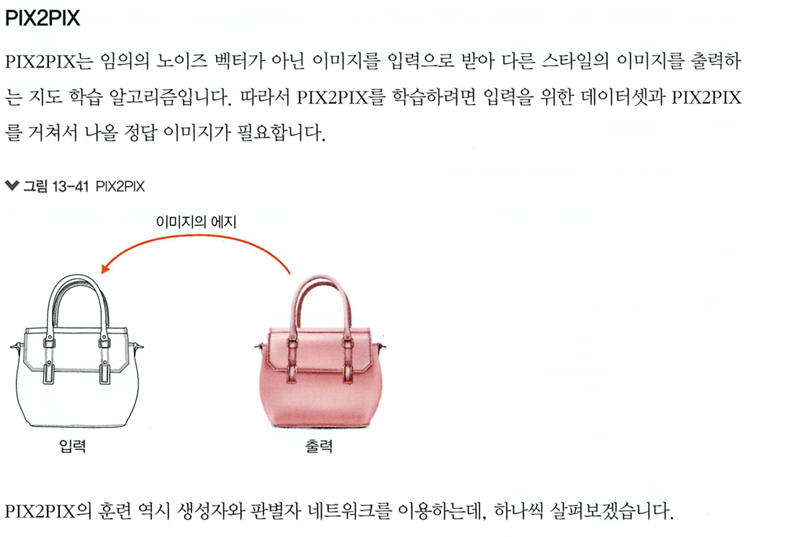

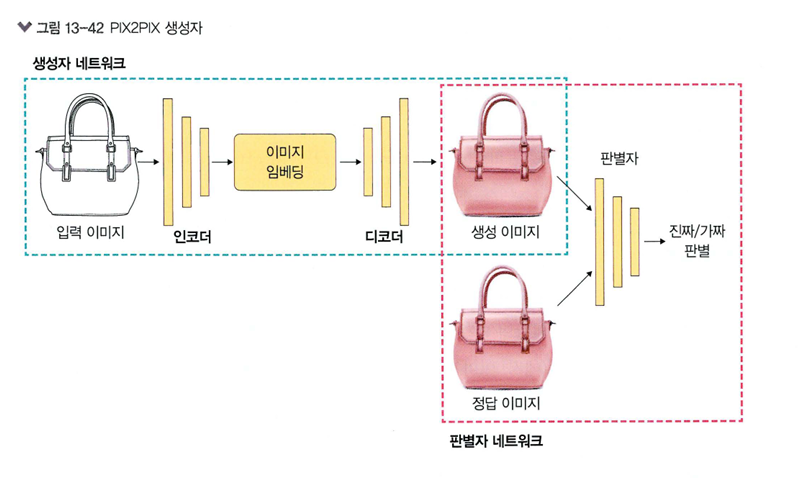

그런데 이러한 데이터 쌍의 이미지를 구하는 것이 쉽지 않습니다. 예를 들어 흑백 이미지를 컬러
이미지로 변경하고 싶다면 동일한 그림에서 채색의 유무만 다른 이미지 두 개가 필요한데， 이러
한 데이터를 얻기 어렵기 때문에 PIX2PIX 모델을 시용하기가 쉽지 않습니다. 따라서 쌍(paircd)
을 이루지 않는 이미지(unpaired irnage)로 학습할 수 있는 방법이 펼요한데 이때 사용하는 것이
CycleGAN입니다.

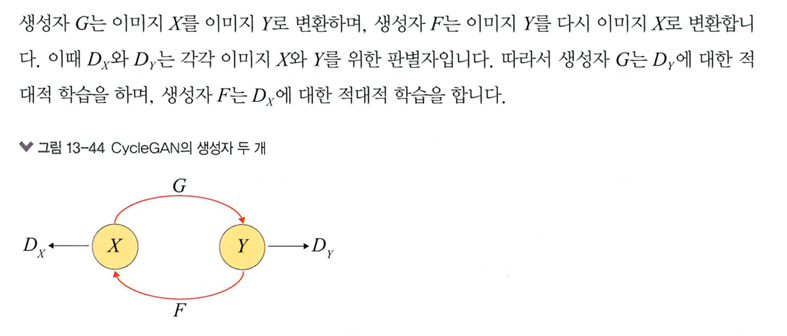